In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Paso de muestreo
    Ts = 1 / fs
    # Vector de tiempo discreto en columna (Nx1)
    tt = np.arange(nn).reshape(-1, 1) * Ts
    # Señal senoidal parametrizada
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx
    

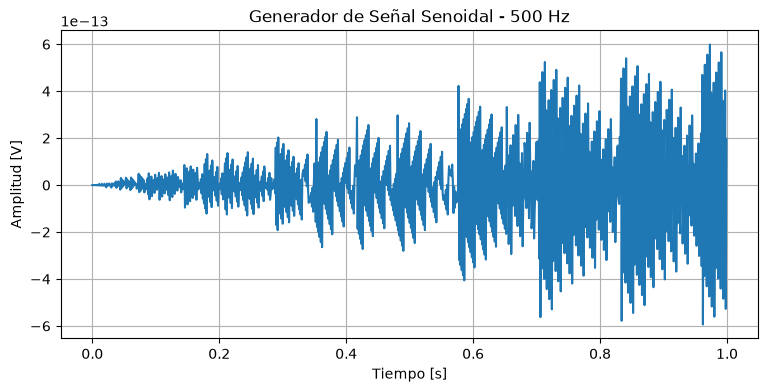

In [4]:
# Probamos con 500 Hz, 1000 muestras y fs = 1000 Hz
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=500, ph=0, nn=1000, fs=1000)

plt.figure(figsize=(9, 4))
plt.plot(tt, xx)
plt.title('Generador de Señal Senoidal - 500 Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

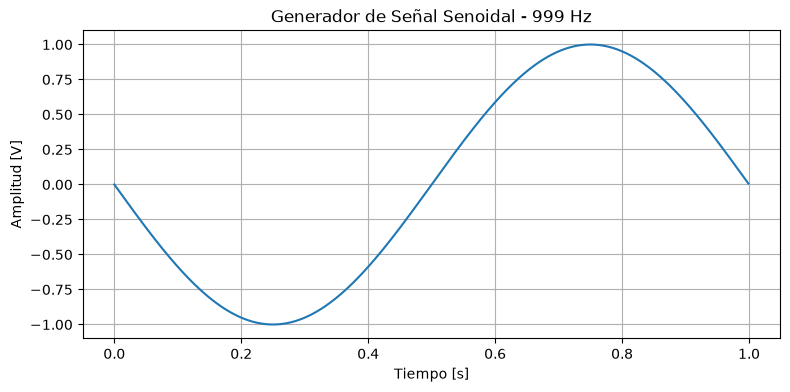

In [7]:
# Probamos con 999 Hz, 1000 muestras y fs = 1000 Hz
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=999, ph=0, nn=1000, fs=1000)

plt.figure(figsize=(9, 4))
plt.plot(tt, xx)
plt.title('Generador de Señal Senoidal - 999 Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

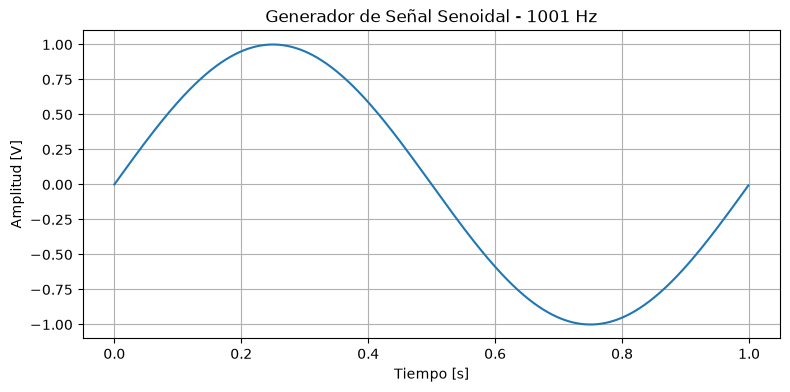

In [6]:
# Probamos con 1001 Hz, 1000 muestras y fs = 1000 Hz
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=1001, ph=0, nn=1000, fs=1000)

plt.figure(figsize=(9, 4))
plt.plot(tt, xx)
plt.title('Generador de Señal Senoidal - 1001 Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

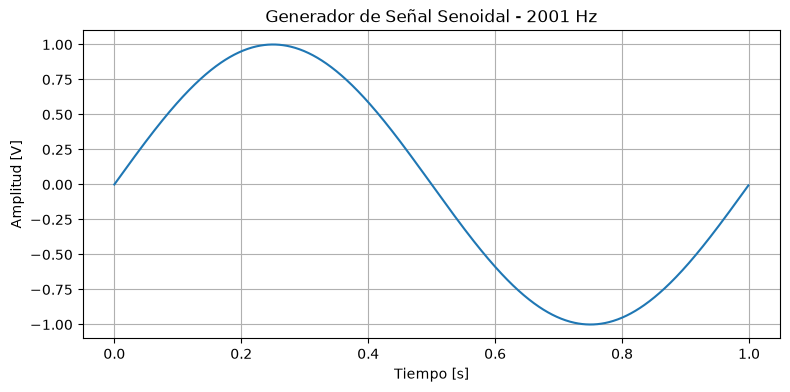

In [8]:
# Probamos con 2001 Hz, 1000 muestras y fs = 1000 Hz
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=2001, ph=0, nn=1000, fs=1000)

plt.figure(figsize=(9, 4))
plt.plot(tt, xx)
plt.title('Generador de Señal Senoidal - 2001 Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

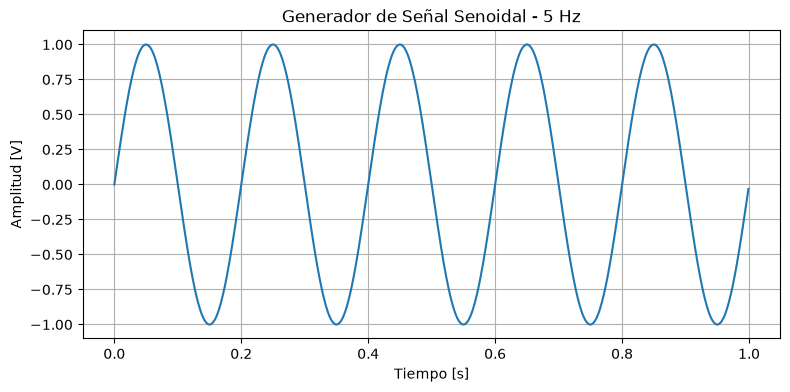

In [9]:
# Probamos con 5 Hz, 1000 muestras y fs = 1000 Hz
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=5, ph=0, nn=1000, fs=1000)

plt.figure(figsize=(9, 4))
plt.plot(tt, xx)
plt.title('Generador de Señal Senoidal - 5 Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

Condición de Nyquist en la frecuencia límite
Al fijar una frecuencia de muestreo de 1000 Hz, la frecuencia límite de Nyquist queda definida en 500 Hz. Cuando la frecuencia de la señal analógica coincide exactamente con este valor, la tasa de digitalización obtiene únicamente dos muestras por cada período de la senoidal. Esto genera una secuencia discreta que conmuta de forma alternada entre los valores pico máximos y mínimos de la señal. Si bien se logra preservar el valor de frecuencia en el dominio discreto, la forma de onda pierde resolución geométrica, quedando representada por una envolvente cuadrada o de trazo triangular al interpolar los puntos.

Fenómeno de Aliasing y solapamiento espectral
Cuando la frecuencia de la señal de entrada supera el límite de Nyquist de 500 Hz, el proceso de muestreo produce un solapamiento espectral. Las componentes de alta frecuencia se pliegan sobre la banda base comprendida entre 0 Hz y la mitad de la frecuencia de muestreo, generando una frecuencia aparente o alias que no corresponde a la señal original.

La frecuencia aparente resultante dentro de la banda base se calcula mediante la siguiente relación:

fa = |ff - k * fs|

Donde fa es la frecuencia percibida, ff es la frecuencia de la señal de entrada, fs es la frecuencia de muestreo y k es un número entero elegido para que el resultado caiga dentro del rango de 0 Hz a 500 Hz.

Evaluación de los casos de prueba

Caso 999 Hz: La frecuencia de la señal se encuentra muy próxima al primer armónico de la frecuencia de muestreo. Al aplicar la relación espectral con k igual a 1, fa = |999 - 1000|, lo que resulta en una frecuencia aparente de 1 Hz. Visual y matemáticamente, los puntos digitalizados trazan una senoidal de baja frecuencia equivalente a 1 Hz.
Caso 1001 Hz: Al superar ligeramente la frecuencia de muestreo de 1000 Hz con k igual a 1, fa = |1001 - 1000|, obteniendo nuevamente una frecuencia aparente de 1 Hz. La secuencia discreta generada es indistinguible de la señal de 1 Hz, presentando únicamente una inversión o desfase respecto al caso de 999 Hz.
Caso 2001 Hz: La frecuencia de la señal supera el doble de la tasa de muestreo. Evaluando el solapamiento para k igual a 2, fa = |2001 - 2 * 1000|, se obtiene nuevamente una representación discreta equivalente a una senoidal de 1 Hz en la banda base.

Este comportamiento demuestra de forma experimental que toda componente espectral que exceda la frecuencia de Nyquist perderá su identidad original y se manifestará como una frecuencia aparente dentro del espectro observable del sistema discreto.
